In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:
#Load the dataset
data=pd.read_csv('CarPrice_Assignment.csv') 
print(data.head())
print(data.info())


   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
#data preprocessing
#dropping unnecessary columns and handling categorical variables
data = data.drop(['CarName','car_ID'],axis=1)
data =pd.get_dummies(data, drop_first=True)

In [4]:
# Splitting the data features and target variable
x = data.drop('price',axis=1)
y = data['price']


In [5]:
# standardizing the data
scaler = StandardScaler()
x= scaler.fit_transform(x)
y = scaler.fit_transform(np.array(y).reshape(-1,1))


In [6]:
#splitting the data set into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
#creating the SGD Regressor model
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)

#Fitting the model on the training model
sgd_model.fit(x_train,y_train)

#making prediction
y_pred = sgd_model.predict(x_test)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
# Evaluated model performance
mse = mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [10]:
#print evaluation metrics
print('Name: devendran G/ AIML')
print('Reg No: 212225240030')
print('Mean Squared Error:',mse)
print('R-Squared Score:',r2)
print('Mean Absolute Error:',mae)


Name: devendran G/ AIML
Reg No: 212225240030
Mean Squared Error: 0.2171000648593007
R-Squared Score: 0.8253430772573465
Mean Absolute Error: 0.32472152436449686


In [11]:
#print model coefficient
print("\nmodel co efficients")
print("co-efficients",sgd_model.coef_)
print("intercept",sgd_model.intercept_)


model co efficients
co-efficients [ 0.03191945  0.1072167   0.01890801  0.17653196  0.01700956  0.16980743
  0.28322965 -0.01753726 -0.08045104  0.00381563  0.10886348  0.03696503
 -0.04393007 -0.05056164 -0.02037613  0.01879207  0.01887419 -0.01829834
 -0.08971992 -0.01370115 -0.0940721  -0.03188286  0.06476568  0.21184852
  0.01543456 -0.0980985   0.07437456 -0.01422591  0.0029919   0.01034671
 -0.03066772 -0.14473999 -0.06766921  0.00075213 -0.02549673  0.01034671
 -0.0052945  -0.01437761  0.02037613 -0.01874414 -0.03130667 -0.04091397
 -0.01719867]
intercept [-0.01074823]


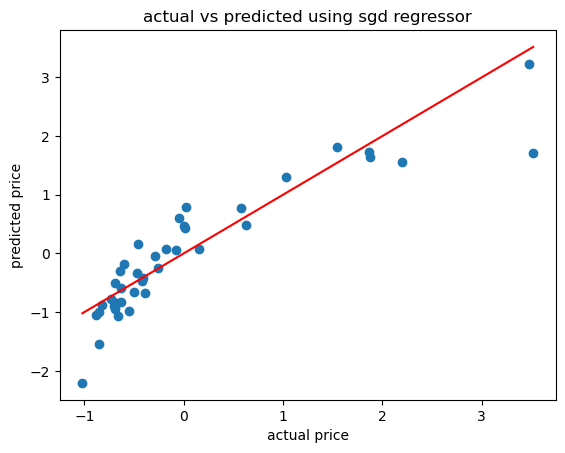

In [13]:
#visualisation actual vs predicted prices
plt.scatter(y_test,y_pred)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted using sgd regressor")
plt.plot([min(y_test),max(y_test)], [min(y_test),max(y_test)],color='red')
plt.show()